In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


In [2]:
pekseg = pd.read_excel("pekseg_demand_forecasting_adatbazis.xlsx")
print(pekseg.head(5))
#replodukálhatóság miatt
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

       Dátum                  Termék Kategória  Eladott mennyiség (db)  \
0 2023-01-02            Fehér kenyér    Kenyér                      40   
1 2023-01-02         Félbarna kenyér    Kenyér                      29   
2 2023-01-02  Teljes kiőrlésű kenyér    Kenyér                      20   
3 2023-01-02             Zsemle (db)    Pékáru                     251   
4 2023-01-02              Kifli (db)    Pékáru                     250   

   Egységár (Ft)  Napi árbevétel (Ft)    Év  Hónap Hét napja  
0            800                32000  2023      1    Monday  
1            850                24650  2023      1    Monday  
2            950                19000  2023      1    Monday  
3             90                22590  2023      1    Monday  
4             85                21250  2023      1    Monday  


In [3]:
#külön csak fehér kenyér
feher_kenyer = pekseg[pekseg["Termék"] == "Fehér kenyér"].copy()
print(feher_kenyer.head(5))

        Dátum        Termék Kategória  Eladott mennyiség (db)  Egységár (Ft)  \
0  2023-01-02  Fehér kenyér    Kenyér                      40            800   
15 2023-01-03  Fehér kenyér    Kenyér                      36            800   
30 2023-01-04  Fehér kenyér    Kenyér                      39            800   
45 2023-01-05  Fehér kenyér    Kenyér                      46            800   
60 2023-01-06  Fehér kenyér    Kenyér                      46            800   

    Napi árbevétel (Ft)    Év  Hónap  Hét napja  
0                 32000  2023      1     Monday  
15                28800  2023      1    Tuesday  
30                31200  2023      1  Wednesday  
45                36800  2023      1   Thursday  
60                36800  2023      1     Friday  


In [4]:
print(feher_kenyer.isna().sum())

Dátum                     0
Termék                    0
Kategória                 0
Eladott mennyiség (db)    0
Egységár (Ft)             0
Napi árbevétel (Ft)       0
Év                        0
Hónap                     0
Hét napja                 0
dtype: int64


In [5]:
feher_kenyer.describe() #seems good 

,Dátum,Eladott mennyiség (db),Egységár (Ft),Napi árbevétel (Ft),Év,Hónap
count,1088,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000
mean,2024-10-01 04:51:10.588235264,94.328125,884.462316,86932.155331,2024.288603,6.074449
min,2023-01-02 00:00:00,29.000000,800.000000,23200.000000,2023.000000,1.000000
25%,2023-11-14 18:00:00,52.000000,800.000000,43250.000000,2023.000000,3.000000
50%,2024-09-30 12:00:00,70.000000,865.000000,63145.000000,2024.000000,6.000000
75%,2025-08-16 12:00:00,98.000000,935.000000,90143.750000,2025.000000,9.000000
max,2026-07-03 00:00:00,470.000000,990.000000,465300.000000,2026.000000,12.000000
std,NaN,68.828105,66.932805,70541.309118,1.031865,3.396379


In [6]:
print(feher_kenyer.columns)

Index(['Dátum', 'Termék', 'Kategória', 'Eladott mennyiség (db)',
       'Egységár (Ft)', 'Napi árbevétel (Ft)', 'Év', 'Hónap', 'Hét napja'],
      dtype='object')


      Demand    Forecast      Error
1084   233.0  288.000000 -55.000000
1085   203.0  275.000000 -72.000000
1086   244.0  238.000000   6.000000
1087   264.0  226.666667  37.333333
1088     NaN  237.000000        NaN


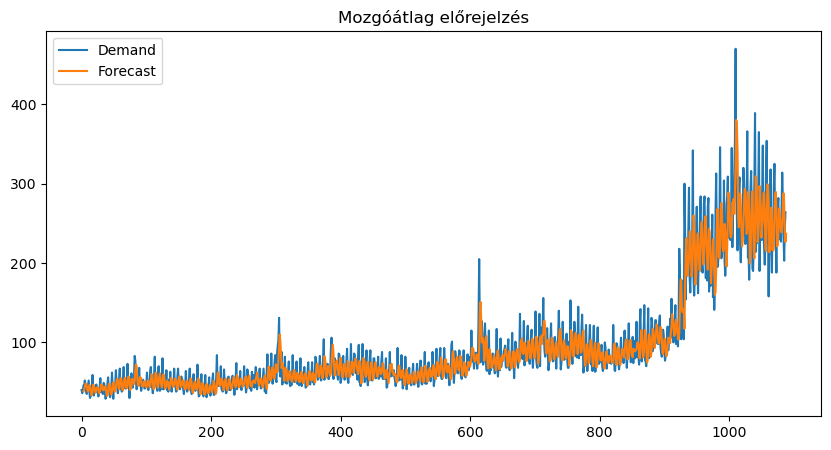

In [7]:
d_values = feher_kenyer["Eladott mennyiség (db)"].values
def moving_average(d, extra_periods=1, n=3):
    # Eredeti adatok hossza
    cols = len(d)

    # Adatok kiterjesztése üres értékekkel a jövőbeli időszakokhoz
    d_extended = np.append(d, [np.nan] * extra_periods)

    # Forecast tömb előkészítése (üres értékekkel)
    f = np.full(cols + extra_periods, np.nan)

    # Előrejelzés kiszámítása a múltbéli adatokra (t+1 logika)
    for t in range(n, cols):
        f[t] = np.mean(d_extended[t-n:t])

    # Előrejelzés a jövőre (az extra_periods szakaszra)
    # Az utolsó ismert n darab adat átlagát vetítjük előre
    if extra_periods > 0:
        f[cols:] = np.mean(d_extended[cols-n:cols])

    # DataFrame összeállítása
    df = pd.DataFrame.from_dict({
        "Demand": d_extended,
        "Forecast": f,
        "Error": d_extended - f
    })
    return df
result = moving_average(d_values, n=3, extra_periods=1)

# 4. Megjelenítés
print(result.tail()) # Az utolsó sorok ellenőrzése
result[["Demand", "Forecast"]].plot(figsize=(10, 5), title="Mozgóátlag előrejelzés")
plt.show()

In [8]:
#ezek napi előrejelzés lehet hogy nekem heti előrejelzés, majd később lehet megcsinálom
def kpi(df):
  dem_ave = df.loc[df["Error"].notnull(),"Demand"].mean()
  bias_abs = df["Error"].mean()
  bias_rel = bias_abs / dem_ave
  print("Bias: {:0.2f}, {:.2%}".format(bias_abs,bias_rel))

  mask = df["Demand"] != 0
  MAPE = (df.loc[mask, "Error"].abs() / df.loc[mask, "Demand"]).mean()

  print("MAPE: {:.2%}".format(MAPE))
  MAE_abs = df["Error"].abs().mean()
  MAE_rel = MAE_abs / dem_ave
  print("MAE: {:0.2f}, {:.2%}".format(MAE_abs,MAE_rel))
  RMSE_abs = np.sqrt((df["Error"]**2).mean())
  RMSE_rel = RMSE_abs / dem_ave
  print("RMSE: {:0.2f}, {:.2%}".format(RMSE_abs, RMSE_rel))
  return {"MAE": MAE_rel, "RMSE": RMSE_rel, "MAPE": MAPE}
kpi_result = kpi(result)
print(kpi_result)

Bias: 0.39, 0.41%
MAPE: 22.95%
MAE: 21.46, 22.71%
RMSE: 30.71, 32.50%
{'MAE': np.float64(0.2271104434516261), 'RMSE': np.float64(0.32498924390080075), 'MAPE': np.float64(0.229491645927241)}


In [9]:
#exponential smoothing

def simple_exp_smooth(d,extra_periods = 1, alpha = 0.4):
  #Historical period length
  cols = len(d)
  #Append np.nan into the demand array to cover future periods
  d  =np.append(d,[np.nan]*extra_periods)
  #Forecast array
  f = np.full(cols + extra_periods,np.nan)
  #initialization of first forecast
  f[1] = d[0]
  #Create all the t+1 forecast until end of historical period
  for t in range(2, cols +1):
    f[t] = alpha*d[t-1]+(1-alpha)*f[t-1]
  #Forecast for all extra periods
  for t in range(cols+1,cols+extra_periods):
    #update the forecast as the previous forecast
    f[t] = f[t-1]
  df = pd.DataFrame.from_dict({"Demand":d,"Forecast":f, "Error":d-f})
  return df

def double_exp_smooth(d, extra_periods=1, alpha=0.4, beta=0.4):
    cols = len(d)
    d = np.append(d, [np.nan] * extra_periods)

    # Tömbök létrehozása
    f, a, b = np.full((3, cols + extra_periods), np.nan)

    # --- JAVÍTOTT INICIALIZÁLÁS ---
    a[0] = d[0]
    b[0] = d[1] - d[0]
    # Az első előrejelzés általában megegyezik az első tényleges adattal
    # vagy a szint+trend összegével a 1. indexen
    f[0] = d[0]

    # Történelmi adatok feldolgozása
    for t in range(1, cols):
        f[t] = a[t-1] + b[t-1]
        a[t] = alpha * d[t] + (1 - alpha) * (a[t-1] + b[t-1])
        b[t] = beta * (a[t] - a[t-1]) + (1 - beta) * b[t-1]

    # Extra periódusok (Forecast)
    for t in range(cols, cols + extra_periods):
        f[t] = a[t-1] + b[t-1]
        a[t] = f[t]
        b[t] = b[t-1]

    df = pd.DataFrame.from_dict({
        "Demand": d,
        "Forecast": f,
        "Level": a,
        "Trend": b,
        "Error": d - f
    })
    return df
def exp_smooth_opti(d, extra_periods=6):
    best_rmse = float('inf')
    best_params = ""
    best_df = None

    # Test both Simple and Double smoothing using the same metric
    alphas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    betas = [0.05, 0.1, 0.2, 0.3, 0.4]

    for alpha in alphas:
        # 1. Evaluate Simple Smoothing
        df_simple = simple_exp_smooth(d, extra_periods=extra_periods, alpha=alpha)
        # Always drop NaN before calculating RMSE to avoid 'nan' results
        rmse_s = np.sqrt(df_simple["Error"].dropna()**2).mean()

        if rmse_s < best_rmse:
            best_rmse = rmse_s
            best_params = f"Simple Smoothing alpha: {alpha}"
            best_df = df_simple

        # 2. Evaluate Double Smoothing
        for beta in betas:
            df_double = double_exp_smooth(d, extra_periods=extra_periods, alpha=alpha, beta=beta)
            rmse_d = np.sqrt(df_double["Error"].dropna()**2).mean()

            if rmse_d < best_rmse:
                best_rmse = rmse_d
                best_params = f"Double Smoothing alpha: {alpha}, beta: {beta}"
                best_df = df_double

    print(f"Best solution found: {best_params} | RMSE: {round(best_rmse, 2)}")
    return best_df
result = exp_smooth_opti(d_values,extra_periods=30)
print(result.tail(7))



Best solution found: Simple Smoothing alpha: 0.1 | RMSE: 16.38
      Demand    Forecast  Error
1111     NaN  251.361213    NaN
1112     NaN  251.361213    NaN
1113     NaN  251.361213    NaN
1114     NaN  251.361213    NaN
1115     NaN  251.361213    NaN
1116     NaN  251.361213    NaN
1117     NaN  251.361213    NaN


probléma mindegyik napra ugyanaz a becslés

      Demand    Forecast       Level     Trend    Season      Error
1084   233.0  295.444504  347.603733 -1.281728  0.720603 -62.444504
1085   203.0  257.511601  302.446986 -5.553875  0.721658 -54.511601
1086   244.0  216.324931  320.280563 -2.715281  0.737638  27.675069
1087   264.0  220.888256  355.056984  1.278265  0.709544  43.111744
1088     NaN  278.196202  356.207423  1.150438  0.780995        NaN


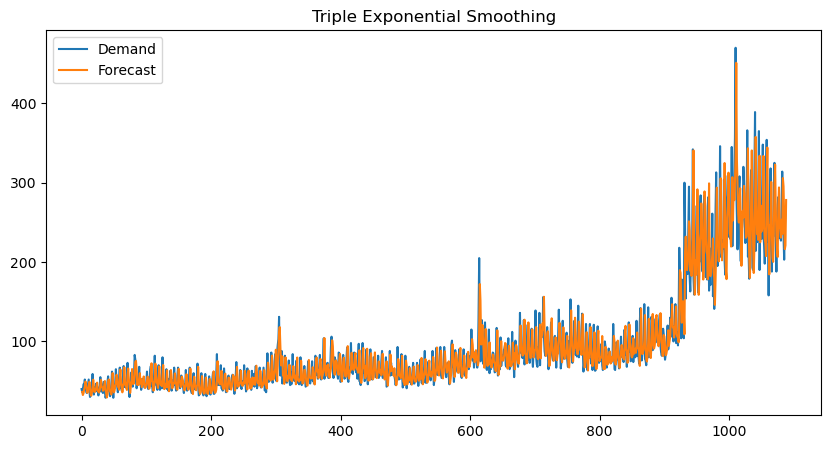

Bias: -0.11, -0.11%
MAPE: 21.21%
MAE: 19.66, 20.84%
RMSE: 29.50, 31.25%
{'MAE': np.float64(0.20835607204853943), 'RMSE': np.float64(0.3125393069849), 'MAPE': np.float64(0.21206290501751296)}


In [10]:
#Triple exponential smoothing

#I am trying to model the seasonality with multiplicative factors and not additive
def seasonal_factors_mul(s,d,slen,cols):
    for i in range(slen):
        s[i] = np.mean(d[i:cols:slen]) #Season average
    s /= np.mean(s[:slen]) # scale all season factors (sum of factors = slen)
    return s
def triple_exp_smooth_mul(d, slen=7, extra_periods=1,
                         alpha=0.6, beta=0.1, phi=0.9, gamma=0.3):#slen lehet 365 is

    cols = len(d)
    d = np.append(d, [np.nan]*extra_periods)

    f, a, b, s = np.full((4, cols + extra_periods), np.nan)

    # Initialize seasonal factors
    s[:slen] = seasonal_factors_mul(np.zeros(slen), d[:cols], slen, cols)

    # Initialization
    a[0] = d[0] / s[0]
    b[0] = (d[1]/s[1]) - (d[0]/s[0])

    # MAIN LOOP
    for t in range(1, cols):
        if t >= slen:
            s_idx = s[t - slen]
        else:
            s_idx = s[t]

        # Forecast
        f[t] = (a[t-1] + phi*b[t-1]) * s_idx

        # Level
        a[t] = alpha * (d[t] / s_idx) + (1 - alpha) * (a[t-1] + phi*b[t-1])

        # Trend
        b[t] = beta * (a[t] - a[t-1]) + (1 - beta) * phi * b[t-1]

        # Seasonality update (only after first full season)
        if t >= slen:
            s[t] = gamma * (d[t] / a[t]) + (1 - gamma) * s[t - slen]

    # Forecast future periods
    for h in range(1, extra_periods + 1):
        t = cols + h - 1
        s_idx = s[t - slen]

        f[t] = (a[cols-1] + phi*b[cols-1]) * s_idx
        a[t] = a[t-1] + phi * b[t-1]
        b[t] = phi * b[t-1]
        s[t] = s_idx

    df = pd.DataFrame({
        "Demand": d,
        "Forecast": f,
        "Level": a,
        "Trend": b,
        "Season": s,
        "Error": d - f
    })

    return df
result = triple_exp_smooth_mul(d_values,slen = 7,extra_periods=1,alpha = 0.6,beta = 0.1,phi = 0.9, gamma = 0.3) #ezt ugye lehet állítani
# 4. Megjelenítés
print(result.tail()) # Az utolsó sorok ellenőrzése
result[["Demand", "Forecast"]].plot(figsize=(10, 5), title="Triple Exponential Smoothing")
plt.show()
kpi_result_triple_exp_smooth = kpi(result)
print(kpi_result_triple_exp_smooth)

In [11]:
print(feher_kenyer.head(5))

        Dátum        Termék Kategória  Eladott mennyiség (db)  Egységár (Ft)  \
0  2023-01-02  Fehér kenyér    Kenyér                      40            800   
15 2023-01-03  Fehér kenyér    Kenyér                      36            800   
30 2023-01-04  Fehér kenyér    Kenyér                      39            800   
45 2023-01-05  Fehér kenyér    Kenyér                      46            800   
60 2023-01-06  Fehér kenyér    Kenyér                      46            800   

    Napi árbevétel (Ft)    Év  Hónap  Hét napja  
0                 32000  2023      1     Monday  
15                28800  2023      1    Tuesday  
30                31200  2023      1  Wednesday  
45                36800  2023      1   Thursday  
60                36800  2023      1     Friday  


In [12]:
print(feher_kenyer.columns)

Index(['Dátum', 'Termék', 'Kategória', 'Eladott mennyiség (db)',
       'Egységár (Ft)', 'Napi árbevétel (Ft)', 'Év', 'Hónap', 'Hét napja'],
      dtype='object')


In [13]:
feher_kenyer["Demand"] = feher_kenyer["Eladott mennyiség (db)"]
#Feature Engineering Hónap, év és nap kinyerése
feher_kenyer["month_idx"] = feher_kenyer["Hónap"]
feher_kenyer["year_idx"] = feher_kenyer["Év"]
feher_kenyer["day_idx"] = feher_kenyer["Dátum"].dt.day
#problémám hogy a feature-k mint például ár vagy napi bevétel nem szívesen tartanám meg viszont lehet hogy fontos az egység árat megtartom
feher_kenyer = feher_kenyer.drop(columns = ["Termék","Kategória"])
feher_kenyer = feher_kenyer.set_index("day_idx")


In [14]:
print(feher_kenyer)


             Dátum  Eladott mennyiség (db)  Egységár (Ft)  \
day_idx                                                     
2       2023-01-02                      40            800   
3       2023-01-03                      36            800   
4       2023-01-04                      39            800   
5       2023-01-05                      46            800   
6       2023-01-06                      46            800   
...            ...                     ...            ...   
29      2026-06-29                     278            990   
30      2026-06-30                     233            990   
1       2026-07-01                     203            990   
2       2026-07-02                     244            990   
3       2026-07-03                     264            990   

         Napi árbevétel (Ft)    Év  Hónap  Hét napja  Demand  month_idx  \
day_idx                                                                   
2                      32000  2023      1     Monday    

In [ ]:
# --- Hétvége flag ---
feher_kenyer['is_weekend'] = (feher_kenyer['dayofweek'] >= 5).astype(int)  # 5=szombat, 6=vasárnap

# --- Iskolai időszak flag ---
# Két intervallum éven belül: szept.1 - dec.20, és jan.6 - jún.15
def is_school_term(date):
    m, d = date.month, date.day
    md = (m, d)
    autumn_term = (9, 1) <= md <= (12, 20)
    spring_term = (1, 6) <= md <= (6, 15)
    return int(autumn_term or spring_term)

feher_kenyer['is_school_term'] = feher_kenyer['Dátum'].apply(is_school_term)

In [15]:
# Napi ciklikus jellemzők
feher_kenyer['dayofweek'] = feher_kenyer['Dátum'].dt.dayofweek   # 0=hétfő
feher_kenyer['dayofyear'] = feher_kenyer['Dátum'].dt.dayofyear

feher_kenyer['dow_sin'] = np.sin(2 * np.pi * feher_kenyer['dayofweek'] / 7)
feher_kenyer['dow_cos'] = np.cos(2 * np.pi * feher_kenyer['dayofweek'] / 7)

feher_kenyer['doy_sin'] = np.sin(2 * np.pi * feher_kenyer['dayofyear'] / 365.25)
feher_kenyer['doy_cos'] = np.cos(2 * np.pi * feher_kenyer['dayofyear'] / 365.25)

feher_kenyer['time_idx'] = np.arange(len(feher_kenyer))

def dataset_with_features(df, x_len=28, y_len=1, test_loops=365):
    demand_values = df['Demand'].values
    dow_sin = df['dow_sin'].values
    dow_cos = df['dow_cos'].values
    doy_sin = df['doy_sin'].values
    doy_cos = df['doy_cos'].values
    time_idx = df['time_idx'].values
    samples = len(demand_values)
    loops = samples + 1 - x_len - y_len

    X, Y = [], []
    for i in range(loops):
        past_demand = demand_values[i : i + x_len]
        t_dow_sin = dow_sin[i+x_len : i+x_len+y_len]
        t_dow_cos = dow_cos[i+x_len : i+x_len+y_len]
        t_doy_sin = doy_sin[i+x_len : i+x_len+y_len]
        t_doy_cos = doy_cos[i+x_len : i+x_len+y_len]
        t_tidx    = time_idx[i+x_len : i+x_len+y_len]

        features = np.concatenate([past_demand, t_dow_sin, t_dow_cos, t_doy_sin, t_doy_cos, t_tidx])
        X.append(features)
        Y.append(demand_values[i+x_len : i+x_len+y_len])

    X, Y = np.array(X), np.array(Y)

    if test_loops > 0:
        X_train, X_test = X[:-test_loops], X[-test_loops:]
        Y_train, Y_test = Y[:-test_loops], Y[-test_loops:]
    else:
        X_train, Y_train = X, Y
        X_test, Y_test = X[-1:], Y[-1:]

    if y_len == 1:
        Y_train, Y_test = Y_train.ravel(), Y_test.ravel()

    return X_train, Y_train, X_test, Y_test

In [ ]:
def dataset_with_features_ratio_v2(df, x_len=28, y_len=1, test_loops=365):
    ratio_values = df['demand_ratio'].values
    baseline_values = df['baseline'].values
    dow_sin, dow_cos = df['dow_sin'].values, df['dow_cos'].values
    doy_sin, doy_cos = df['doy_sin'].values, df['doy_cos'].values
    is_weekend = df['is_weekend'].values
    is_school = df['is_school_term'].values
    dates = df['Dátum'].values
    samples = len(ratio_values)
    loops = samples + 1 - x_len - y_len

    X, Y, base_target, date_target = [], [], [], []
    for i in range(loops):
        past_ratio = ratio_values[i : i + x_len]
        t = slice(i + x_len, i + x_len + y_len)
        features = np.concatenate([
            past_ratio,
            dow_sin[t], dow_cos[t], doy_sin[t], doy_cos[t],
            is_weekend[t], is_school[t]          # <- új
        ])
        X.append(features)
        Y.append(ratio_values[t])
        base_target.append(baseline_values[t])
        date_target.append(dates[t][0])

    X, Y, base_target = np.array(X), np.array(Y), np.array(base_target)
    date_target = np.array(date_target)
    X_train, X_test = X[:-test_loops], X[-test_loops:]
    Y_train, Y_test = Y[:-test_loops], Y[-test_loops:]
    base_train, base_test = base_target[:-test_loops].ravel(), base_target[-test_loops:].ravel()
    date_train, date_test = date_target[:-test_loops], date_target[-test_loops:]
    return X_train, Y_train.ravel(), X_test, Y_test.ravel(), base_train, base_test, date_train, date_test

In [ ]:
from dateutil.easter import easter
import pandas as pd

def hungarian_holidays(year):
    e = pd.Timestamp(easter(year))  # Húsvétvasárnap
    return {
        pd.Timestamp(year,1,1):  "Újév",
        pd.Timestamp(year,3,15): "1848 forradalom",
        e - pd.Timedelta(days=2): "Nagypéntek",
        e:                        "Húsvétvasárnap",
        e + pd.Timedelta(days=1): "Húsvéthétfő",
        pd.Timestamp(year,5,1):  "Munka ünnepe",
        e + pd.Timedelta(days=49): "Pünkösdvasárnap",
        e + pd.Timedelta(days=50): "Pünkösdhétfő",
        pd.Timestamp(year,8,20): "Államalapítás",
        pd.Timestamp(year,10,23):"1956 forradalom",
        pd.Timestamp(year,11,1): "Mindenszentek",
        pd.Timestamp(year,12,25):"Karácsony",
        pd.Timestamp(year,12,26):"Karácsony 2. napja",
    }

years = range(feher_kenyer['Dátum'].dt.year.min(), feher_kenyer['Dátum'].dt.year.max() + 1)
HOLIDAY_MAP = {}
for y in years:
    HOLIDAY_MAP.update(hungarian_holidays(y))
HOLIDAYS = set(HOLIDAY_MAP.keys())

feher_kenyer['is_holiday'] = feher_kenyer['Dátum'].isin(HOLIDAYS).astype(int)

# "közeli nap" jelző: ünnep előtti/utáni ±2 nap (megnövekedett bevásárlási kedv)
NEAR_WINDOW = 2
near_holiday_dates = {h + pd.Timedelta(days=d)
                       for h in HOLIDAYS
                       for d in range(-NEAR_WINDOW, NEAR_WINDOW + 1)
                       if d != 0}
near_holiday_dates -= HOLIDAYS  # ne fedje az is_holiday-t
feher_kenyer['is_near_holiday'] = feher_kenyer['Dátum'].isin(near_holiday_dates).astype(int)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_train, Y_train, X_test, Y_test = dataset_with_features(feher_kenyer)

# Scaling
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
Y_train_sc = scaler_Y.fit_transform(Y_train.reshape(-1, 1)).ravel()

# Tanítás
reg = LinearRegression()
reg.fit(X_train_sc, Y_train_sc)

# Predikció + inverse transform
Y_train_pred = scaler_Y.inverse_transform(reg.predict(X_train_sc).reshape(-1, 1)).ravel()
Y_test_pred  = scaler_Y.inverse_transform(reg.predict(X_test_sc).reshape(-1, 1)).ravel()

In [17]:
def kpi_ML(Y_train, Y_train_pred, Y_test, Y_test_pred, name=""):
    metrics = pd.DataFrame(columns=["MAE", "RMSE", "Bias"], index=["Train", "Test"])
    metrics.index.name = name
    
    # Számítások
    for label, actual, pred in [("Train", Y_train, Y_train_pred), ("Test", Y_test, Y_test_pred)]:
        metrics.loc[label, "MAE"] = 100 * np.mean(abs(actual - pred)) / np.mean(actual)
        metrics.loc[label, "RMSE"] = 100 * np.sqrt(np.mean((actual - pred)**2)) / np.mean(actual)
        metrics.loc[label, "Bias"] = 100 * np.mean(pred - actual) / np.mean(actual)
        
    print(metrics.astype(float).round(1))

In [18]:
kpi_ML(Y_train, Y_train_pred,Y_test,Y_test_pred, name = "Linear Regression")

                    MAE  RMSE  Bias
Linear Regression                  
Train              10.4  14.7   0.0
Test               19.6  30.2 -16.5


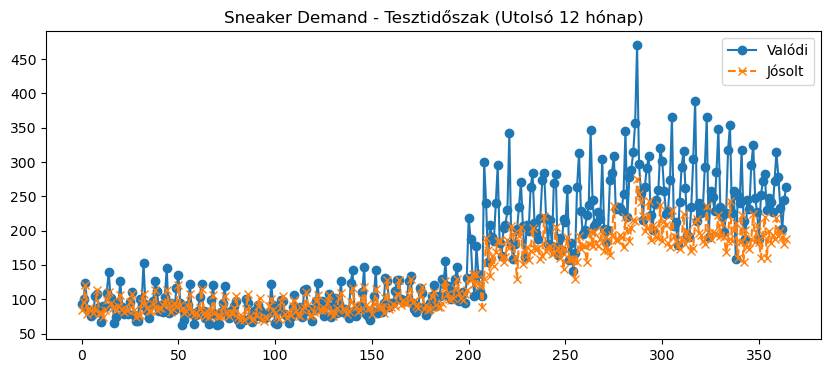

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(Y_test)), Y_test, label="Valódi", marker='o')
plt.plot(range(len(Y_test)), Y_test_pred, label="Jósolt", marker='x', linestyle='--')
plt.title("Sneaker Demand - Tesztidőszak (Utolsó 12 hónap)")
plt.legend()
plt.show()

Legjobb paraméterek: {'max_depth': 6, 'min_samples_leaf': 3}
                     MAE  RMSE  Bias
DecisionTree_tuned                  
Train                8.6  11.8  -0.0
Test                43.1  61.4 -38.8


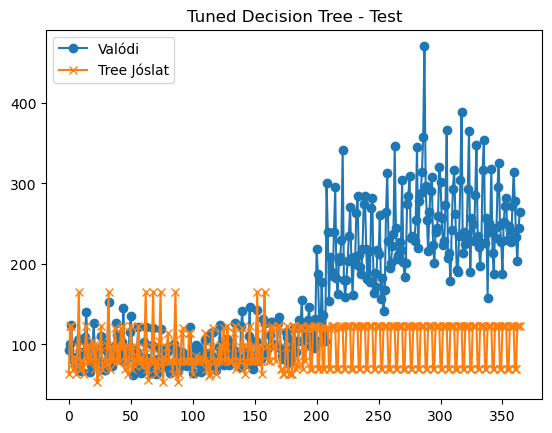

lag_6      0.642041
lag_12     0.102568
lag_18     0.050110
lag_1      0.043289
doy_cos    0.037280
dow_cos    0.027519
lag_2      0.024171
lag_10     0.016440
dow_sin    0.014127
lag_24     0.009437
lag_17     0.006472
lag_19     0.004775
lag_5      0.004097
lag_3      0.004006
lag_4      0.003011
dtype: float64


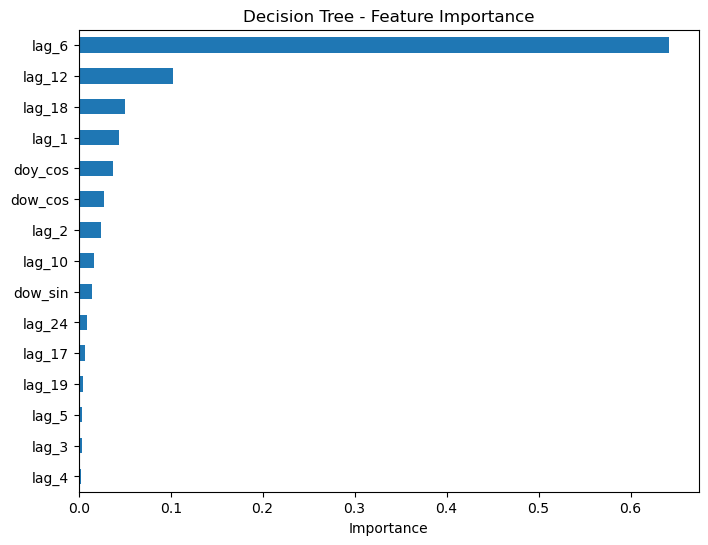

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# --- 2. time_idx kivétele a fa feature-ei közül ---
# a dataset_with_features-ben a sorrend: [past_demand(28), dow_sin, dow_cos, doy_sin, doy_cos, time_idx]
# time_idx mindig az utolsó oszlop -> egyszerűen levágjuk

def build_features_flag(df, x_len=28, y_len=1, test_loops=365, include_time_idx=False):
    X_train, Y_train, X_test, Y_test = dataset_with_features(df, x_len=x_len, y_len=y_len, test_loops=test_loops)
    if not include_time_idx:
        X_train, X_test = X_train[:, :-1], X_test[:, :-1]
    return X_train, Y_train, X_test, Y_test

X_train, Y_train, X_test, Y_test = build_features_flag(
    feher_kenyer, x_len=28, y_len=1, test_loops=365, include_time_idx=False
)

# --- 3. Hiperparaméter keresés TimeSeriesSplit-tel (csak a train adaton, X_test-hez nem nyúlunk) ---
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8],
    "min_samples_leaf": [3, 5, 10, 20],
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
grid.fit(X_train, Y_train)

print("Legjobb paraméterek:", grid.best_params_)
tree = grid.best_estimator_

# Predikció a végleges (best_estimator_) fával
Y_train_pred = tree.predict(X_train)
Y_test_pred = tree.predict(X_test)

kpi_ML(Y_train, Y_train_pred, Y_test, Y_test_pred, name="DecisionTree_tuned")

plt.plot(Y_test, label="Valódi", marker='o')
plt.plot(Y_test_pred, label="Tree Jóslat", marker='x')
plt.legend()
plt.title("Tuned Decision Tree - Test")
plt.show()

# --- Feature importance ---
x_len = 28
feature_names = [f"lag_{x_len - j}" for j in range(x_len)] + ["dow_sin", "dow_cos", "doy_sin", "doy_cos"]
# ha include_time_idx=True volt, illeszd hozzá: feature_names.append("time_idx")

importances = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.head(15))

importances.head(15).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Decision Tree - Feature Importance")
plt.xlabel("Importance")
plt.show()

In [21]:
#következő algoritmus Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(bootstrap=True, max_samples = 0.95, max_features=11, min_samples_leaf =18,max_depth = 7 , random_state = SEED)
rf_model.fit(X_train, Y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,18
,min_weight_fraction_leaf,0.0
,max_features,11
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
Y_train_pred = rf_model.predict(X_train)
Y_test_pred = rf_model.predict(X_test)
kpi_ML(Y_train, Y_train_pred, Y_test,Y_test_pred, name = "Forecast")

           MAE  RMSE  Bias
Forecast                  
Train     10.5  15.7   0.1
Test      43.5  63.7 -41.1


Legjobb RF paraméterek: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_samples': 0.7, 'max_features': 16, 'max_depth': 7}
                     MAE  RMSE  Bias
RandomForest_tuned                  
Train                8.5  12.6   0.0
Test                38.5  57.4 -35.9


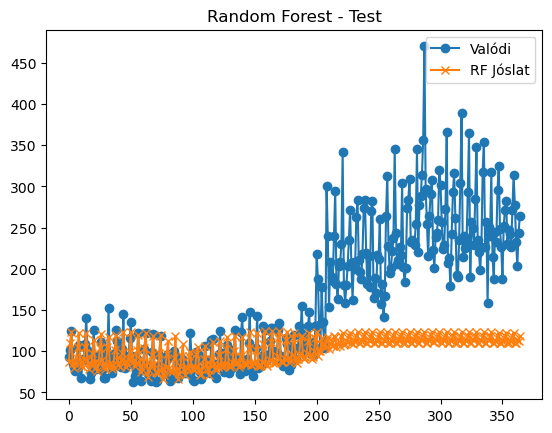

lag_6      0.349208
lag_12     0.205213
lag_18     0.128301
lag_24     0.059590
lag_1      0.058194
dow_sin    0.025436
lag_5      0.017609
doy_cos    0.014066
lag_7      0.013026
lag_19     0.012104
lag_11     0.011865
lag_2      0.008777
lag_17     0.007847
lag_13     0.007549
lag_14     0.007362
dtype: float64


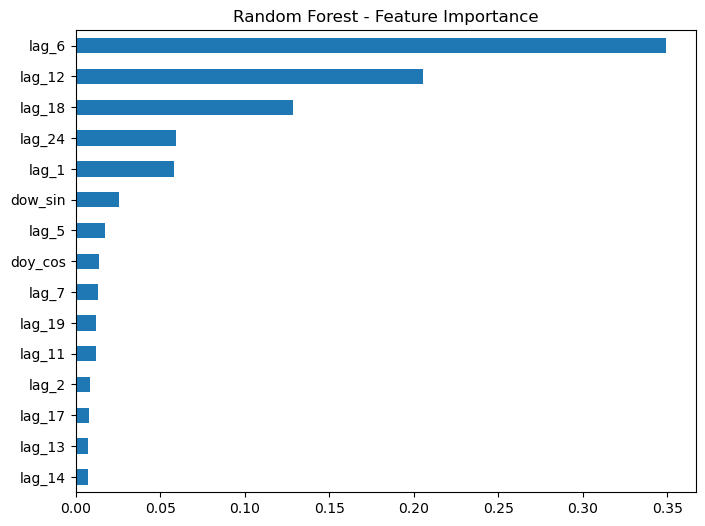

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 5, 6, 7, 8],
    "min_samples_leaf": [5, 10, 18, 25],
    "max_features": [6, 8, 11, 16, "sqrt"],
    "max_samples": [0.7, 0.8, 0.95, None],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(bootstrap=True, random_state=SEED),
    param_distributions=param_dist,
    n_iter=25,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=SEED,
    n_jobs=-1,
)
rf_search.fit(X_train, Y_train)

print("Legjobb RF paraméterek:", rf_search.best_params_)
rf_model = rf_search.best_estimator_

Y_train_pred = rf_model.predict(X_train)
Y_test_pred  = rf_model.predict(X_test)

kpi_ML(Y_train, Y_train_pred, Y_test, Y_test_pred, name="RandomForest_tuned")

plt.plot(Y_test, label="Valódi", marker='o')
plt.plot(Y_test_pred, label="RF Jóslat", marker='x')
plt.legend()
plt.title("Random Forest - Test")
plt.show()

# Feature importance (ugyanazokkal a nevekkel, mint a fánál)
x_len = 28
feature_names = [f"lag_{x_len - j}" for j in range(x_len)] + ["dow_sin", "dow_cos", "doy_sin", "doy_cos"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.head(15))

importances.head(15).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Random Forest - Feature Importance")
plt.show()

In [24]:
# 1. Gördülő alapszint - csak MÚLTBELI adatot használ (shift(1)!), nem szivárogtat
feher_kenyer['baseline'] = feher_kenyer['Demand'].shift(1).rolling(28, min_periods=28).mean()
feher_kenyer_ratio = feher_kenyer.dropna(subset=['baseline']).copy()
feher_kenyer_ratio['demand_ratio'] = feher_kenyer_ratio['Demand'] / feher_kenyer_ratio['baseline']

def dataset_with_features_ratio(df, x_len=28, y_len=1, test_loops=365):
    ratio_values = df['demand_ratio'].values
    baseline_values = df['baseline'].values
    dow_sin, dow_cos = df['dow_sin'].values, df['dow_cos'].values
    doy_sin, doy_cos = df['doy_sin'].values, df['doy_cos'].values
    samples = len(ratio_values)
    loops = samples + 1 - x_len - y_len

    X, Y, base_target = [], [], []
    for i in range(loops):
        past_ratio = ratio_values[i : i + x_len]
        t = slice(i + x_len, i + x_len + y_len)
        features = np.concatenate([past_ratio, dow_sin[t], dow_cos[t], doy_sin[t], doy_cos[t]])
        X.append(features)
        Y.append(ratio_values[t])
        base_target.append(baseline_values[t])

    X, Y, base_target = np.array(X), np.array(Y), np.array(base_target)

    X_train, X_test = X[:-test_loops], X[-test_loops:]
    Y_train, Y_test = Y[:-test_loops], Y[-test_loops:]
    base_train, base_test = base_target[:-test_loops], base_target[-test_loops:]

    if y_len == 1:
        Y_train, Y_test = Y_train.ravel(), Y_test.ravel()
        base_train, base_test = base_train.ravel(), base_test.ravel()

    return X_train, Y_train, X_test, Y_test, base_train, base_test

X_train, Yr_train, X_test, Yr_test, base_train, base_test = dataset_with_features_ratio(feher_kenyer_ratio)

tree = DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, random_state=42)
tree.fit(X_train, Yr_train)

# Vissza abszolút Demand-be: predikció = arány * aznapi baseline
Y_train_actual, Y_test_actual = Yr_train * base_train, Yr_test * base_test
Y_train_pred = tree.predict(X_train) * base_train
Y_test_pred  = tree.predict(X_test) * base_test

kpi_ML(Y_train_actual, Y_train_pred, Y_test_actual, Y_test_pred, name="DecisionTree_ratio")

                     MAE  RMSE  Bias
DecisionTree_ratio                  
Train                7.3  10.1   0.1
Test                12.3  18.0  -1.2


In [25]:
from sklearn.ensemble import ExtraTreesRegressor
ETR = ExtraTreesRegressor(n_jobs=-1,n_estimators=200,min_samples_split=15, min_samples_leaf=4, max_samples=0.95,max_features=4, max_depth=8,bootstrap=True,random_state  =SEED) #same inut parameters as before

ETR.fit(X_train,Yr_train)
Y_train_actual, Y_test_actual = Yr_train * base_train, Yr_test * base_test
Y_train_pred = ETR.predict(X_train)*base_train
Y_test_pred = ETR.predict(X_test)*base_test

kpi_ML(Y_train_actual,Y_train_pred,Y_test_actual,Y_test_pred, name = "ETR")

        MAE  RMSE  Bias
ETR                    
Train  10.4  15.2   0.1
Test   11.1  17.3  -1.8


In [26]:
max_depth = list(range(3, 13)) + [None]
min_samples_split = range(2, 16)
min_samples_leaf = range(2, 13)
max_features = range(5, 13)
tscv = TimeSeriesSplit(n_splits=5)
bootstrap = [True]
max_samples = [0.7, 0.8, 0.9, 0.95]

param_dist = {
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'max_features': max_features,
    'bootstrap': bootstrap,
    'max_samples': max_samples,
}

ETR = ExtraTreesRegressor(n_jobs=1, n_estimators=30, random_state=SEED)  # random_state a reprodukálhatóságért
ETR_cv = RandomizedSearchCV(
    ETR, param_dist, cv=tscv, verbose=2, n_jobs=-1,
    n_iter=400, scoring='neg_mean_absolute_error', random_state=SEED
)
ETR_cv.fit(X_train, Yr_train)

print("Tuned Forest Parameters:", ETR_cv.best_params_)

# Fontos: a tuningolt, betanított modellt kell használni predikcióhoz
best_etr = ETR_cv.best_estimator_

Y_train_actual, Y_test_actual = Yr_train * base_train, Yr_test * base_test
Y_train_pred = best_etr.predict(X_train) * base_train
Y_test_pred  = best_etr.predict(X_test) * base_test

kpi_ML(Y_train_actual, Y_train_pred, Y_test_actual, Y_test_pred, name="ETR")

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Tuned Forest Parameters: {'min_samples_split': 9, 'min_samples_leaf': 3, 'max_samples': 0.8, 'max_features': 12, 'max_depth': 8, 'bootstrap': True}
        MAE  RMSE  Bias
ETR                    
Train   8.6  12.5   0.2
Test   10.6  16.2  -1.8


Depth: 2 kész. Legjobb MAE ebben a körben: 0.12
Depth: 3 kész. Legjobb MAE ebben a körben: 0.11
Depth: 4 kész. Legjobb MAE ebben a körben: 0.11
Depth: 5 kész. Legjobb MAE ebben a körben: 0.11

--- VÉGSŐ MODELL ---
Legjobb mélység: 5
Legjobb paraméterek: {'n_estimators': 100, 'loss': 'square', 'learning_rate': 0.01}
                MAE  RMSE  Bias
Best AdaBoost                  
Train           7.7  10.1   0.3
Test           10.3  15.4  -0.9


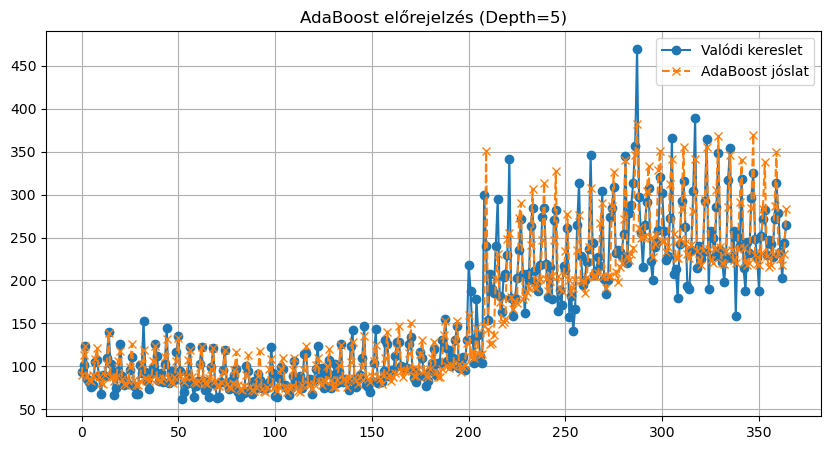

In [27]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd


# 2. CV beállítása (n_splits=3 biztonságos ilyen kevés adatnál)
tscv = TimeSeriesSplit(n_splits=3)
results = []

# 3. Paraméter tér AdaBoost-hoz
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'loss': ['linear', 'square', 'exponential'],
    'n_estimators': [50, 100, 150]
}

# 4. Optimalizációs ciklus
for max_depth in range(2, 6):
    base = DecisionTreeRegressor(max_depth=max_depth)
    ada = AdaBoostRegressor(estimator=base, random_state=42)

    ada_cv = RandomizedSearchCV(
        ada, 
        param_dist, 
        n_jobs=-1, 
        cv=tscv, 
        n_iter=20, 
        scoring='neg_mean_absolute_error',
        random_state=42
    )
    
    try:
        ada_cv.fit(X_train, Yr_train)
        # Elmentjük: Score, Paraméterek, Mélység
        results.append({
            'score': ada_cv.best_score_,
            'params': ada_cv.best_params_,
            'depth': max_depth,
            'model': ada_cv.best_estimator_
        })
        print(f"Depth: {max_depth} kész. Legjobb MAE ebben a körben: {-ada_cv.best_score_:.2f}")
    except ValueError as e:
        print(f"Depth {max_depth} kihagyva hiba miatt: {e}")

# --- EZ A "TÖBBI KÓD" RÉSZ, AMIT KERESTÉL ---

# 5. A legjobb modell kiválasztása az összes próbálkozás közül
# A legmagasabb neg_MAE-t keressük (ami a legkisebb hiba)
best_run = max(results, key=lambda x: x['score'])
print(f"\n--- VÉGSŐ MODELL ---")
print(f"Legjobb mélység: {best_run['depth']}")
print(f"Legjobb paraméterek: {best_run['params']}")

# 6. A legjobb modell betanítása és predikció
final_model = best_run['model']

Y_train_actual, Y_test_actual = Yr_train * base_train, Yr_test * base_test
Y_train_pred = final_model.predict(X_train) * base_train
Y_test_pred  = final_model.predict(X_test) * base_test


# 7. KPI-ok megjelenítése
# Feltételezve, hogy a korábbi kpi_ML függvényed definiálva van
kpi_ML(Y_train_actual, Y_train_pred, Y_test_actual, Y_test_pred, name="Best AdaBoost")

# 8. Grafikon a jövőbeli trendről (opcionális, de ajánlott)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(len(Y_test)), Y_test_actual, label="Valódi kereslet", marker='o')
plt.plot(range(len(Y_test)), Y_test_pred, label="AdaBoost jóslat", marker='x', linestyle='--')
plt.title(f"AdaBoost előrejelzés (Depth={best_run['depth']})")
plt.legend()
plt.grid(True)
plt.show()

Legjobb XGB paraméterek: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


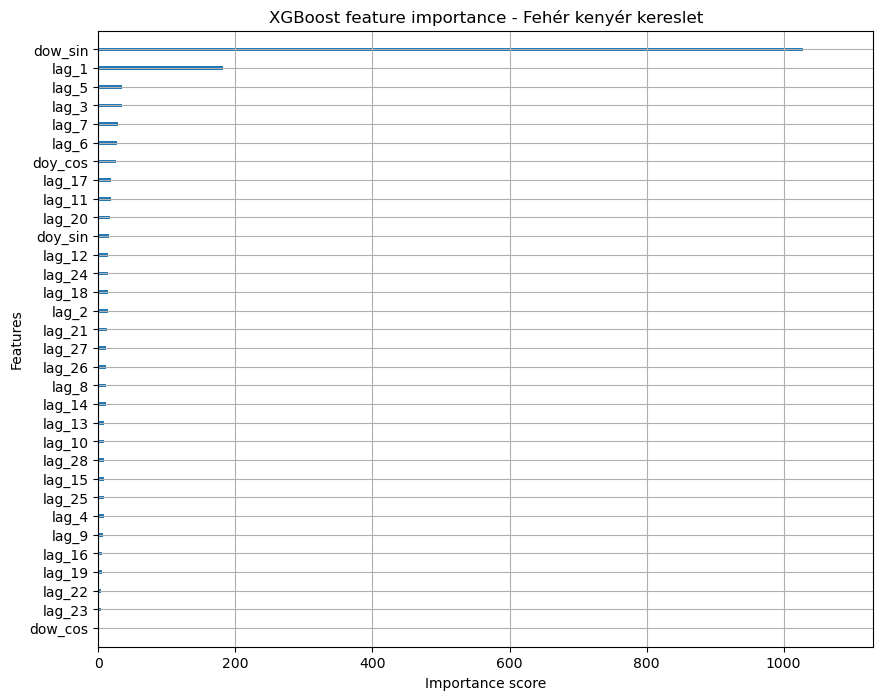

         MAE  RMSE  Bias
XGBoost                 
Train    6.4   8.9  -0.1
Test     9.9  14.8  -1.9


In [28]:
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "max_depth": [3, 4, 5, 6, 8],
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

XGB_base = XGBRegressor(n_jobs=-1, random_state=42, objective="reg:squarederror")

XGB_cv = RandomizedSearchCV(
    XGB_base, param_dist, cv=tscv, n_iter=100,
    scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1
)
XGB_cv.fit(X_train, Yr_train)
print("Legjobb XGB paraméterek:", XGB_cv.best_params_)

XGB = XGB_cv.best_estimator_

# Feature nevek - a TÉNYLEGES feature-készlethez igazítva (28 lag + 4 szezonális, nincs time_idx)
x_len = 28
feature_names = [f"lag_{x_len - j}" for j in range(x_len)] + ["dow_sin", "dow_cos", "doy_sin", "doy_cos"]
assert len(feature_names) == X_train.shape[1], "Feature nevek száma nem egyezik az oszlopszámmal!"
XGB.get_booster().feature_names = feature_names

plt.figure(figsize=(10, 8))
xgb.plot_importance(XGB, importance_type='total_gain', show_values=False, ax=plt.gca())
plt.title("XGBoost feature importance - Fehér kenyér kereslet")
plt.show()

Y_train_actual, Y_test_actual = Yr_train * base_train, Yr_test * base_test
Y_train_pred = XGB.predict(X_train) * base_train
Y_test_pred  = XGB.predict(X_test) * base_test

kpi_ML(Y_train_actual, Y_train_pred, Y_test_actual, Y_test_pred, name="XGBoost")

In [29]:
best_params = {k: v for k, v in XGB_cv.best_params_.items() if k != "n_estimators"}

# Időrendi (nem random!) validation szelet a train VÉGÉRŐL - pl. utolsó 10%
n_val = int(len(X_train) * 0.1)
X_sub_train, X_val = X_train[:-n_val], X_train[-n_val:]
Yr_sub_train, Yr_val = Yr_train[:-n_val], Yr_train[-n_val:]

XGB_probe = XGBRegressor(
    n_jobs=-1,
    n_estimators=1000,          # magas felső korlát, az early stopping úgyis megáll
    early_stopping_rounds=50,
    eval_metric='mae',
    **best_params
)
XGB_probe.fit(
    X_sub_train, Yr_sub_train,
    eval_set=[(X_val, Yr_val)],
    verbose=False
)
best_iter = XGB_probe.get_booster().best_iteration
print("Optimális fa-szám:", best_iter)

# Végső modell: TELJES X_train-en, fix n_estimators-szal, nincs adatvesztés
XGB = XGBRegressor(n_jobs=-1, n_estimators=best_iter, **best_params)
XGB.fit(X_train, Yr_train)

# Kiértékelés - a baseline visszaszorzással!
Y_train_actual, Y_test_actual = Yr_train * base_train, Yr_test * base_test
Y_train_pred = XGB.predict(X_train) * base_train
Y_test_pred  = XGB.predict(X_test) * base_test

kpi_ML(Y_train_actual, Y_train_pred, Y_test_actual, Y_test_pred, name='Tuned XGBoost')

Optimális fa-szám: 375
                MAE  RMSE  Bias
Tuned XGBoost                  
Train           6.9   9.8  -0.1
Test           10.0  14.8  -1.9


In [ ]:
#cost of producing waste: előállítása költség munkaerő + tárolás  + alapanyag ár nagyjűból egységár 70  %
#oppurtinity cost: a bevétel amit akkor kaptak volna ha eladnak egy terméket ez nagyjából az ár 30 % 
#nagyjából spórolás mértéke: (eddig készített  - általam javasolt) * cost of waste - (eddig készített - általam javasolt ) * opportunity cost


In [30]:
def dataset_with_features_ratio(df, x_len=28, y_len=1, test_loops=365):
    ratio_values = df['demand_ratio'].values
    baseline_values = df['baseline'].values
    dow_sin, dow_cos = df['dow_sin'].values, df['dow_cos'].values
    doy_sin, doy_cos = df['doy_sin'].values, df['doy_cos'].values
    dates = df['Dátum'].values
    samples = len(ratio_values)
    loops = samples + 1 - x_len - y_len

    X, Y, base_target, date_target = [], [], [], []
    for i in range(loops):
        past_ratio = ratio_values[i : i + x_len]
        t = slice(i + x_len, i + x_len + y_len)
        features = np.concatenate([past_ratio, dow_sin[t], dow_cos[t], doy_sin[t], doy_cos[t]])
        X.append(features)
        Y.append(ratio_values[t])
        base_target.append(baseline_values[t])
        date_target.append(dates[t][0])   # <- dátum hozzáadva

    X, Y, base_target = np.array(X), np.array(Y), np.array(base_target)
    date_target = np.array(date_target)

    X_train, X_test = X[:-test_loops], X[-test_loops:]
    Y_train, Y_test = Y[:-test_loops], Y[-test_loops:]
    base_train, base_test = base_target[:-test_loops], base_target[-test_loops:]
    date_train, date_test = date_target[:-test_loops], date_target[-test_loops:]

    return (X_train, Y_train.ravel(), X_test, Y_test.ravel(),
            base_train.ravel(), base_test.ravel(), date_train, date_test)

# --- Ugyanaz a 29. cellás pipeline, csak dátummal kiegészítve ---
X_train, Yr_train, X_test, Yr_test, base_train, base_test, date_train, date_test = \
    dataset_with_features_ratio(feher_kenyer_ratio)

best_params = {k: v for k, v in XGB_cv.best_params_.items() if k != "n_estimators"}

n_val = int(len(X_train) * 0.1)
X_sub_train, X_val = X_train[:-n_val], X_train[-n_val:]
Yr_sub_train, Yr_val = Yr_train[:-n_val], Yr_train[-n_val:]

XGB_probe = XGBRegressor(n_jobs=-1, n_estimators=1000, early_stopping_rounds=50,
                          eval_metric='mae', random_state=42, **best_params)
XGB_probe.fit(X_sub_train, Yr_sub_train, eval_set=[(X_val, Yr_val)], verbose=False)
best_iter = XGB_probe.get_booster().best_iteration

XGB = XGBRegressor(n_jobs=-1, n_estimators=best_iter, random_state=42, **best_params)
XGB.fit(X_train, Yr_train)

# Predikciók visszaszorzása a baseline-nal -> abszolút darabszám
Y_test_actual = Yr_test * base_test
Y_test_pred   = XGB.predict(X_test) * base_test

# Csak a 2026-os napok kiválogatása
res = pd.DataFrame({
    'Dátum': pd.to_datetime(date_test),
    'actual_demand': Y_test_actual,
    'suggested_production': Y_test_pred
})
df2026 = res[res['Dátum'].dt.year == 2026].reset_index(drop=True)

In [32]:
SAFETY_BUFFER_OLD = 25   # a régi gyakorlat becsült biztonsági többlete (db) — állítsd a valós értékre
SAFETY_BUFFER_NEW = 10   # a Tuned XGBoost javaslatához hozzáadott biztonsági többlet (db)

# 'res' a 29. cellás Tuned XGBoost predikciókból jön (lásd előző válasz, date_test-tel kiegészítve)
df2026 = res[res['Dátum'].dt.year == 2026].copy().reset_index(drop=True)

fk = feher_kenyer[['Dátum', 'Egységár (Ft)']].copy()
df2026 = df2026.merge(fk, on='Dátum', how='left')
df2026.rename(columns={'Egységár (Ft)': 'unit_price'}, inplace=True)

# --- Javasolt gyártás: modell predikció + biztonsági puffer ---
df2026['suggested_production'] = df2026['suggested_production'] + SAFETY_BUFFER_NEW

# --- Régi gyártás: tényleges kereslet + becsült régi puffer ---
df2026['old_production'] = df2026['actual_demand'] + SAFETY_BUFFER_OLD

Co = df2026['unit_price'] * 0.70
Cu = df2026['unit_price'] * 0.30

df2026['old_cost'] = (np.maximum(df2026['old_production'] - df2026['actual_demand'], 0) * Co
                     + np.maximum(df2026['actual_demand'] - df2026['old_production'], 0) * Cu)

df2026['new_cost'] = (np.maximum(df2026['suggested_production'] - df2026['actual_demand'], 0) * Co
                     + np.maximum(df2026['actual_demand'] - df2026['suggested_production'], 0) * Cu)

df2026['savings'] = df2026['old_cost'] - df2026['new_cost']

total_savings = df2026['savings'].sum()
print(f"Teljes becsült spórolás 2026-ban (eddig, {SAFETY_BUFFER_OLD} db régi puffer mellett): {total_savings:,.0f} Ft")

Teljes becsült spórolás 2026-ban (eddig, 25 db régi puffer mellett): 630,626 Ft


In [ ]:
#amit még meg kell tennem az az hogy külső faktorok pl iskola hét, hétvége szerinti felosztás, időjárás esetleg
#ezt feltérképezni Co/Cu csak feltételezés, nem mért értékAz egész üzleti döntés (mennyit termelj) ezen az arányon áll vagy bukik — most még találgatás
#~3,5 év adat, nincs élő visszacsatolásNincs monitoring/újratanítási pipeline, ami észrevenné, ha romlik a pontosság

In [ ]:
# 1. Ünnepi szorzó KIZÁRÓLAG a train-időszakból mérve (nem a tesztből, hogy ne szivárogjon adat)
test_loops = 365
train_part = feher_kenyer.iloc[:-test_loops]

normal_mean = train_part.loc[~(train_part.is_holiday | train_part.is_near_holiday), 'Demand'].mean()
holiday_mult = train_part.loc[train_part.is_holiday, 'Demand'].mean() / normal_mean
near_mult    = train_part.loc[train_part.is_near_holiday, 'Demand'].mean() / normal_mean

# 2. A nyers XGBoost predikcióra ráültetjük a szabályt
df2026['pred_corrected'] = df2026['suggested_production']  # nyers modell predikció
df2026.loc[df2026.is_holiday, 'pred_corrected'] = df2026.loc[df2026.is_holiday, 'suggested_production'] * holiday_mult
df2026.loc[df2026.is_near_holiday, 'pred_corrected'] = df2026.loc[df2026.is_near_holiday, 'suggested_production'] * near_mult